# 07 · ANALYSES_TODO — recompute-only closes the paper gaps

Runs every item of `ANALYSES_TODO.md` from the existing logs (no retraining):
§1 text↔figure reconciliation (regenerate H0/H1/H2/H4 in a unified convention:
median **test** mAP@R in **%**), §6 headline + floor classification, §5 profile-vs-MDS
full budget, §2 secondary metrics, §3 convergence, §4 hybrid status. Prints are laid
out to fill `FINDINGS.md`. Run after `00` (reads `results.csv`).

In [1]:
import os, sys
sys.path.insert(0, os.getcwd())
import pandas as pd
import analysis_utils as au
pd.set_option("display.width", 130); pd.set_option("display.max_columns", 30)
df = pd.read_csv("results.csv")
print("runs:", len(df), "| phase5:", (df.phase=='phase5').sum())

runs: 224 | phase5: 60


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


figures regenerated: fig_h0_lambda, fig_h1_headline, fig_h2_norm, fig_h4_overlay, fig_h3_probe, fig_convergence


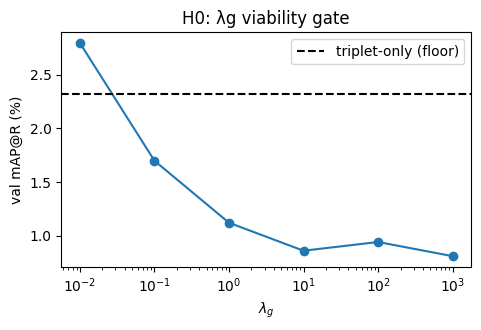

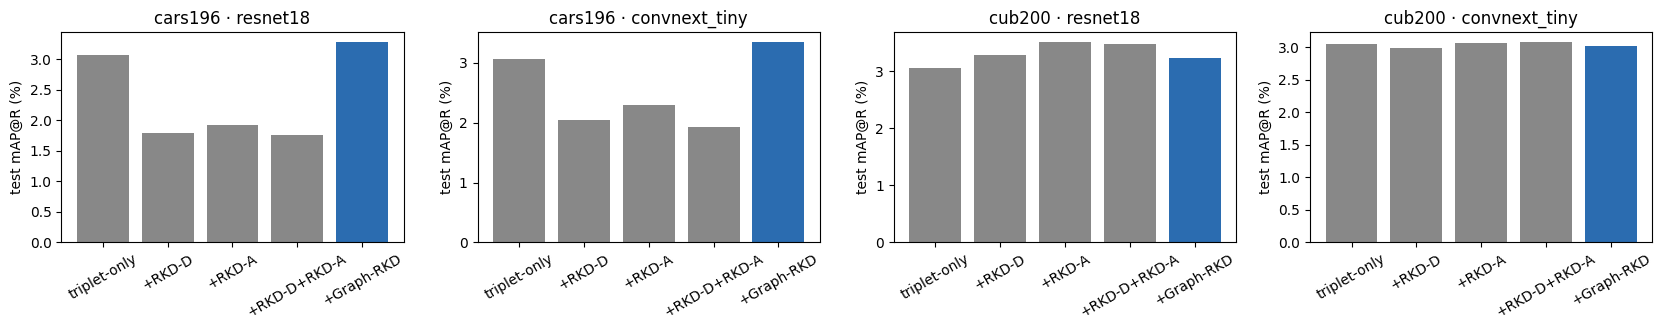

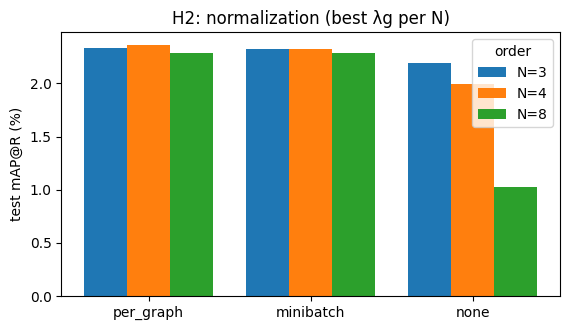

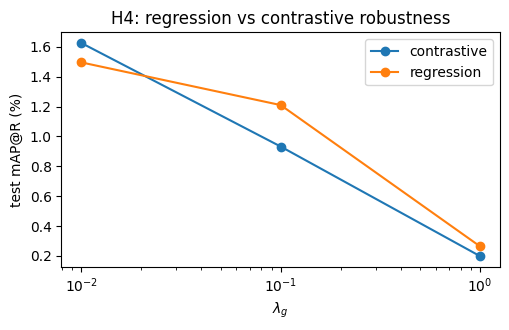

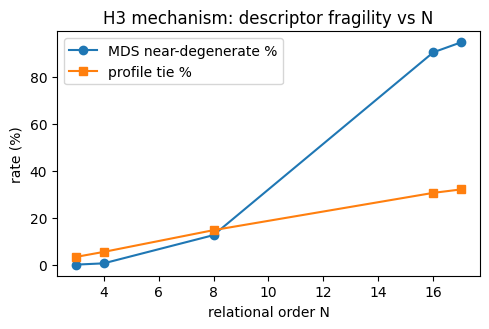

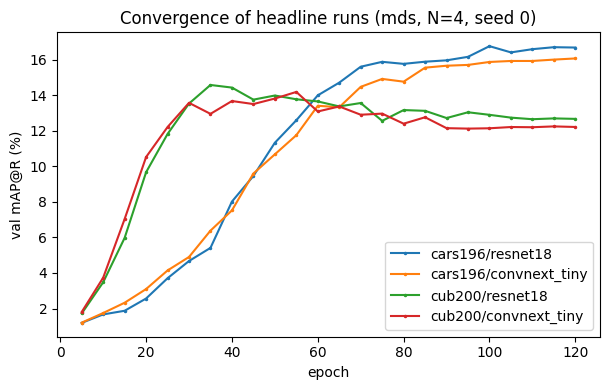

In [2]:
# --- §1: regenerate ALL mAP figures in the unified convention (test mAP@R %) ---
au.fig_h0_lambda(df); au.fig_h1_bar(df); au.fig_h2_norm(df)
au.fig_h4_overlay(df); au.fig_probe()
conv, _ = au.convergence(df)      # also saves fig_convergence.pdf
print("figures regenerated: fig_h0_lambda, fig_h1_headline, fig_h2_norm, fig_h4_overlay, fig_h3_probe, fig_convergence")

In [3]:
# --- §1: reconciled values behind the figures (unified convention) ---
print("H0 gate (phase1, Cars/R18) val mAP@R %:")
h0 = au.agg(df[(df.phase=='phase1')&(df.student=='graph-rkd')].dropna(subset=['lambda_g','val_mAP@R']),
            ['lambda_g'],'val_mAP@R').sort_values('lambda_g')
h0['val%'] = (h0['median']*100).round(2); print(h0[['lambda_g','val%','n']].to_string(index=False))
floor = df[(df.phase=='phase1')&(df.student=='triplet_only')]['val_mAP@R'].dropna()
print("  floor val%:", round(floor.mean()*100,2))
print()
print("H2 normalization (phase2) best-λg median TEST mAP@R %, per norm×N:")
per = au.agg(df[(df.phase=='phase2')&(df.student=='graph-rkd')].dropna(subset=['norm']),
             ['norm','N','lambda_g'],'test_mAP@R')
best = per.loc[per.groupby(['norm','N'])['median'].idxmax()].copy()
best['test%'] = (best['median']*100).round(2)
print(best[['norm','N','lambda_g','test%','n']].sort_values(['norm','N']).to_string(index=False))
print()
print("H4 objective (phase4) median TEST mAP@R %, per objective×λg:")
t4 = au.agg(df[(df.phase=='phase4')&(df.student=='graph-rkd')],['objective','lambda_g'],'test_mAP@R')
t4['test%'] = (t4['median']*100).round(2)
print(t4[['objective','lambda_g','test%','n']].sort_values(['objective','lambda_g']).to_string(index=False))

H0 gate (phase1, Cars/R18) val mAP@R %:
 lambda_g  val%  n
     0.01  2.80  1
     0.10  1.70  1
     1.00  1.12  1
    10.00  0.86  1
   100.00  0.94  1
  1000.00  0.81  1
  floor val%: 2.32

H2 normalization (phase2) best-λg median TEST mAP@R %, per norm×N:
     norm   N  lambda_g  test%  n
minibatch 3.0      0.01   2.32  2
minibatch 4.0      0.01   2.33  2
minibatch 8.0      0.01   2.29  2
     none 3.0      0.01   2.19  2
     none 4.0      0.01   2.00  2
     none 8.0      0.01   1.03  2
per_graph 3.0      0.01   2.34  2
per_graph 4.0      0.01   2.36  2
per_graph 8.0      0.01   2.29  2

H4 objective (phase4) median TEST mAP@R %, per objective×λg:
  objective  lambda_g  test%  n
contrastive      0.01   1.63  1
contrastive      0.10   0.93  1
contrastive      1.00   0.20  1
 regression      0.01   1.50  1
 regression      0.10   1.21  1
 regression      1.00   0.26  1


In [4]:
# --- §6: headline 5×4 (strict mds/N4 for Graph-RKD) + floor classification ---
print("HEADLINE MATRIX (median test mAP@R %):"); print(au.headline_matrix(df).to_string())
print("\nper-cell n (Graph-RKD strict mds/N4):")
print(au.headline_long(df).pivot(index='student', columns='cell', values='n').reindex(au.STUDENT_ORDER).to_string())
print("\nFLOOR CLASSIFICATION (noise=13% rel):")
print(au.floor_classification(df).to_string(index=False))

HEADLINE MATRIX (median test mAP@R %):
cell          cars196/resnet18  cars196/convnext_tiny  cub200/resnet18  cub200/convnext_tiny
triplet-only              3.07                   3.07             3.05                  3.05
+RKD-D                    1.79                   2.05             3.29                  2.98
+RKD-A                    1.93                   2.29             3.50                  3.07
+RKD-D+RKD-A              1.76                   1.93             3.48                  3.08
+Graph-RKD                3.20                   3.35             3.12                  3.08

per-cell n (Graph-RKD strict mds/N4):
cell          cars196/convnext_tiny  cars196/resnet18  cub200/convnext_tiny  cub200/resnet18
student                                                                                     
triplet_only                      3                 3                     2                2
rkd_dist                          3                 3                     2          

In [5]:
# --- §5: profile vs MDS at FULL budget (phase5, N=3) ---
print("profile vs MDS (full budget, N=3, median test mAP@R %):")
print(au.profile_vs_mds_full(df, N=3).to_string(index=False))

profile vs MDS (full budget, N=3, median test mAP@R %):
                 cell  profile  mds  delta_prof_minus_mds  n_profile  n_mds
     cars196/resnet18     3.57 3.28                  0.30          3      3
cars196/convnext_tiny     3.31 3.34                 -0.02          2      2
      cub200/resnet18     3.31 3.03                  0.28          2      2
 cub200/convnext_tiny     3.13 2.98                  0.16          2      2


In [6]:
# --- §2: secondary metrics (median test %, per dataset) + qualitative R@1 check ---
sec = au.secondary_metrics(df)
for ds in ('cars196','cub200'):
    print(f"== {ds} =="); print(sec[ds].to_string(index=False)); print()
print("Graph-RKD (mds/N4) per-cell R@1 % (vs qualitative citation 25.3/24.6 Cars, 14.3/15.0 CUB):")
print(au.headline_long(df, 'test_recall@1')[au.headline_long(df,'test_recall@1').student=='graph-rkd'].to_string(index=False))

== cars196 ==
     student   R@1   R@2   R@4   R@8  R-Prec
triplet-only 20.96 30.08 41.34 54.05    8.75
      +RKD-D 14.24 21.08 30.28 41.67    6.50
      +RKD-A 14.28 21.40 30.86 42.84    6.89
+RKD-D+RKD-A 13.59 20.38 29.66 40.92    6.49
  +Graph-RKD 23.67 33.07 44.05 56.36    9.11

== cub200 ==
     student   R@1   R@2   R@4   R@8  R-Prec
triplet-only 14.30 21.79 31.76 44.02    8.34
      +RKD-D 15.27 22.48 32.22 44.84    8.45
      +RKD-A 15.92 23.70 33.55 46.03    8.77
+RKD-D+RKD-A 15.77 23.50 34.19 46.72    8.87
  +Graph-RKD 14.58 21.75 31.16 43.76    8.23

Graph-RKD (mds/N4) per-cell R@1 % (vs qualitative citation 25.3/24.6 Cars, 14.3/15.0 CUB):


  student                  cell  median_pct  n
graph-rkd      cars196/resnet18       22.00  3
graph-rkd cars196/convnext_tiny       24.12  2
graph-rkd       cub200/resnet18       14.58  2
graph-rkd  cub200/convnext_tiny       14.14  2


In [7]:
# --- §4: hybrid normalization status ---
h = au.hybrid_status(df)
print("hybrid runs found:", len(h))
print(h.to_string(index=False) if len(h) else "NONE — hybrid not executed")

hybrid runs found: 4
                                  run phase dataset  teacher  method   objective   N  lambda_g  seed  val_mAP@R  test_mAP@R
dev-cars-r18-prof-reg-hy-N4-lg0p01-s0   dev cars196 resnet18 profile  regression 4.0      0.01     0      2.974       0.706
dev-cars-r18-prof-con-hy-N4-lg0p01-s0   dev cars196 resnet18 profile contrastive 4.0      0.01     0      1.719       0.580
 dev-cars-r18-mds-reg-hy-N4-lg0p01-s0   dev cars196 resnet18     mds  regression 4.0      0.01     0      1.125       0.193
 dev-cars-r18-mds-con-hy-N4-lg0p01-s0   dev cars196 resnet18     mds contrastive 4.0      0.01     0      1.076       0.169


In [8]:
# --- Q1: teacher quality vs student outcome ---
for ds in ('cars196','cub200'):
    for t in ('resnet18','convnext_tiny'):
        s = df[(df.dataset==ds)&(df.teacher==t)]['teacher_test_mAP@R'].dropna()
        if len(s): print(f"teacher {ds}/{t}: {round(s.median()*100,2)}% test mAP@R")
print("\n(student outcomes are the headline matrix above)")
au.export_tables(df)   # refresh tables/*.{csv,tex}

teacher cars196/resnet18: 19.07% test mAP@R
teacher cars196/convnext_tiny: 36.42% test mAP@R


teacher cub200/resnet18: 18.07% test mAP@R
teacher cub200/convnext_tiny: 29.3% test mAP@R

(student outcomes are the headline matrix above)


[tables] 8 tables -> /home/gabomfim/code/MO434/RKD/analysis/tables: ['headline_cars196_resnet18', 'headline_cars196_convnext_tiny', 'headline_cub200_resnet18', 'headline_cub200_convnext_tiny', 'h2_normalization', 'h3_descriptor', 'h4_objective', 'h5_n3_vs_rkda']


['headline_cars196_resnet18',
 'headline_cars196_convnext_tiny',
 'headline_cub200_resnet18',
 'headline_cub200_convnext_tiny',
 'h2_normalization',
 'h3_descriptor',
 'h4_objective',
 'h5_n3_vs_rkda']